# European Luxury Quality & Valuation Screen

**Research question:** Which of five European luxury companies currently shows the strongest *operating quality* based on growth, profitability, balance-sheet resilience and margin momentum?

This notebook reproduces the workbook calculations and an illustrative Ferrari DCF. It deliberately separates **company quality** from **stock attractiveness**: no current share prices or valuation multiples are used in the peer ranking.

**Sources:** official FY2025/FY2024 results and investor-relations pages for Ferrari, LVMH, Hermes, Moncler and Brunello Cucinelli. See the workbook `Sources` sheet and project README for URLs.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
DATA = BASE / 'data'
CHARTS = BASE / 'charts'
CHARTS.mkdir(exist_ok=True)

df = pd.read_csv(DATA / 'luxury_reported_financials.csv')
df

,Company,Revenue_2023_EURm,Revenue_2024_EURm,Revenue_2025_EURm,EBIT_2023_EURm,EBIT_2024_EURm,EBIT_2025_EURm,NetProfit_2023_EURm,NetProfit_2024_EURm,NetProfit_2025_EURm,NetCash_2025_EURm
0,Ferrari,5970.0,6677.0,7146.0,1617.0,1888.0,2110.0,1257.0,1526.0,1600.0,-32.0
1,LVMH,86153.0,84683.0,80807.0,22802.0,19571.0,17755.0,15174.0,12550.0,10878.0,-6857.0
2,Hermes,13427.0,15170.0,16002.0,5650.0,6144.0,6569.0,4311.0,4597.0,4524.0,12239.0
3,Moncler,2984.2,3108.9,3132.1,893.8,916.3,913.4,611.9,639.6,626.7,1458.0
4,Brunello Cucinelli,1139.0,1278.5,1408.0,187.4,211.7,227.8,107.5,128.5,142.0,-198.4


## 1. Derive comparable operating metrics

Recurring operating profit is used as the EBIT proxy where that is the issuer's primary operating-profit disclosure. This is suitable for a high-level screen but not a full accounting harmonization exercise.

In [2]:
df['Revenue_CAGR_2023_25'] = (df['Revenue_2025_EURm'] / df['Revenue_2023_EURm'])**0.5 - 1
df['EBIT_Margin_2023'] = df['EBIT_2023_EURm'] / df['Revenue_2023_EURm']
df['EBIT_Margin_2025'] = df['EBIT_2025_EURm'] / df['Revenue_2025_EURm']
df['Net_Margin_2025'] = df['NetProfit_2025_EURm'] / df['Revenue_2025_EURm']
df['NetCash_to_Revenue'] = df['NetCash_2025_EURm'] / df['Revenue_2025_EURm']
df['EBIT_Margin_Change'] = df['EBIT_Margin_2025'] - df['EBIT_Margin_2023']

metrics = ['Company','Revenue_CAGR_2023_25','EBIT_Margin_2025','Net_Margin_2025','NetCash_to_Revenue','EBIT_Margin_Change']
df[metrics].style.format({c:'{:.1%}' for c in metrics[1:]})

,Company,Revenue_CAGR_2023_25,EBIT_Margin_2025,Net_Margin_2025,NetCash_to_Revenue,EBIT_Margin_Change
0,Ferrari,9.4%,29.5%,22.4%,-0.4%,2.4%
1,LVMH,-3.2%,22.0%,13.5%,-8.5%,-4.5%
2,Hermes,9.2%,41.1%,28.3%,76.5%,-1.0%
3,Moncler,2.4%,29.2%,20.0%,46.6%,-0.8%
4,Brunello Cucinelli,11.2%,16.2%,10.1%,-14.1%,-0.3%


## 2. Transparent quality score

Each metric is min-max scaled within this five-company peer set. Weights are:

- Revenue CAGR: 25%
- 2025 EBIT margin: 25%
- 2025 net margin: 20%
- Net cash / revenue: 15%
- EBIT-margin momentum: 15%

Because the peer set is small, the score is sensitive to outliers. It is a structured comparison, not an investment recommendation.

In [3]:
score_inputs = {
    'Growth_Score': 'Revenue_CAGR_2023_25',
    'EBIT_Margin_Score': 'EBIT_Margin_2025',
    'Net_Margin_Score': 'Net_Margin_2025',
    'Balance_Sheet_Score': 'NetCash_to_Revenue',
    'Momentum_Score': 'EBIT_Margin_Change',
}
for score_col, raw_col in score_inputs.items():
    lo, hi = df[raw_col].min(), df[raw_col].max()
    df[score_col] = 50 if hi == lo else 100 * (df[raw_col] - lo) / (hi - lo)

weights = {
    'Growth_Score': 0.25,
    'EBIT_Margin_Score': 0.25,
    'Net_Margin_Score': 0.20,
    'Balance_Sheet_Score': 0.15,
    'Momentum_Score': 0.15,
}
df['Weighted_Score'] = sum(df[k] * v for k, v in weights.items())
df['Rank'] = df['Weighted_Score'].rank(ascending=False, method='min').astype(int)
ranking = df[['Company','Weighted_Score','Rank']].sort_values('Rank')
ranking

,Company,Weighted_Score,Rank
2,Hermes,88.982895,1
0,Ferrari,66.110177,2
3,Moncler,51.787820,3
4,Brunello Cucinelli,34.127381,4
1,LVMH,10.464410,5


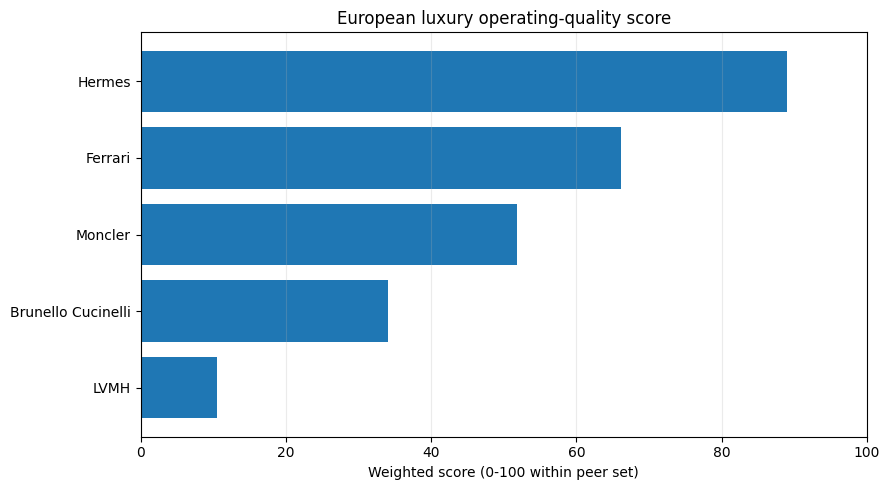

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
plot_df = ranking.sort_values('Weighted_Score')
ax.barh(plot_df['Company'], plot_df['Weighted_Score'])
ax.set_title('European luxury operating-quality score')
ax.set_xlabel('Weighted score (0-100 within peer set)')
ax.set_xlim(0,100)
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS / 'luxury_quality_score.png', dpi=200, bbox_inches='tight')
plt.show()

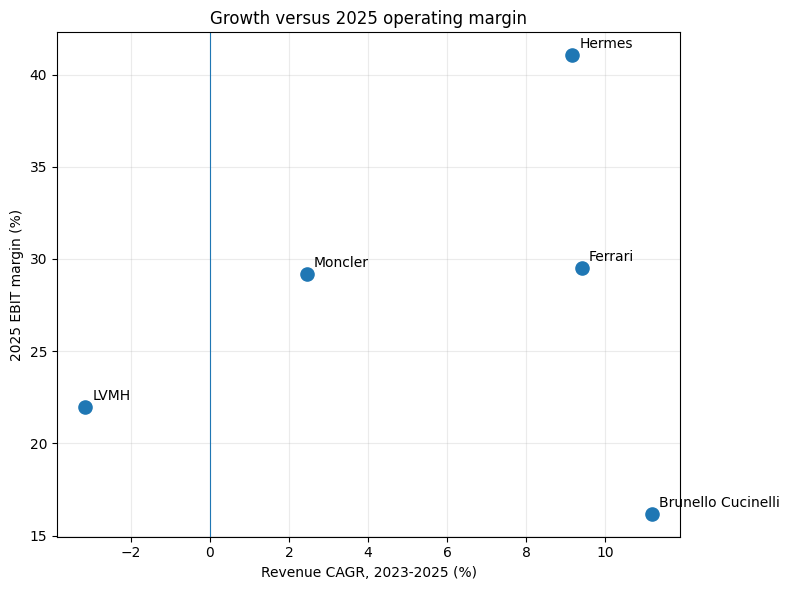

In [5]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df['Revenue_CAGR_2023_25']*100, df['EBIT_Margin_2025']*100, s=90)
for _, row in df.iterrows():
    ax.annotate(row['Company'], (row['Revenue_CAGR_2023_25']*100, row['EBIT_Margin_2025']*100), xytext=(5,5), textcoords='offset points')
ax.axvline(0, linewidth=0.8)
ax.set_title('Growth versus 2025 operating margin')
ax.set_xlabel('Revenue CAGR, 2023-2025 (%)')
ax.set_ylabel('2025 EBIT margin (%)')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS / 'luxury_growth_margin.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Illustrative Ferrari DCF

The DCF uses FY2025 industrial free cash flow as the starting point. It is deliberately simple and should be presented as a sensitivity exercise, not a target price. A full model would forecast revenue segments, margins, capex, working capital, taxes and share-count details.

In [6]:
base_fcf = 1538.0  # EURm, FY2025 industrial FCF
growth = [0.10, 0.09, 0.08, 0.07, 0.06]
wacc = 0.085
terminal_growth = 0.03
net_debt = 32.0
shares_m = 179.0

fcfs = []
current = base_fcf
for g in growth:
    current *= (1+g)
    fcfs.append(current)
discount_factors = np.array([1/(1+wacc)**i for i in range(1,6)])
pv_forecast = float(np.dot(fcfs, discount_factors))
terminal_value = fcfs[-1]*(1+terminal_growth)/(wacc-terminal_growth)
pv_terminal = terminal_value*discount_factors[-1]
equity_value = pv_forecast + pv_terminal - net_debt
value_per_share = equity_value/shares_m

pd.DataFrame({
    'Year':['2026E','2027E','2028E','2029E','2030E'],
    'Growth':growth,
    'FCF_EURm':fcfs,
    'DiscountFactor':discount_factors,
    'PV_EURm':np.array(fcfs)*discount_factors,
}).style.format({'Growth':'{:.1%}','FCF_EURm':'{:,.1f}','DiscountFactor':'{:.3f}','PV_EURm':'{:,.1f}'})

,Year,Growth,FCF_EURm,DiscountFactor,PV_EURm
0,2026E,10.0%,"1,691.8",0.922,"1,559.3"
1,2027E,9.0%,"1,844.1",0.849,"1,566.4"
2,2028E,8.0%,"1,991.6",0.783,"1,559.2"
3,2029E,7.0%,"2,131.0",0.722,"1,537.7"
4,2030E,6.0%,"2,258.9",0.665,"1,502.2"


In [7]:
wacc_grid = np.arange(0.075, 0.100, 0.005)
g_grid = np.arange(0.020, 0.045, 0.005)
sensitivity = pd.DataFrame(index=[f'{x:.1%}' for x in wacc_grid], columns=[f'{x:.1%}' for x in g_grid], dtype=float)
for w in wacc_grid:
    dfs = np.array([1/(1+w)**i for i in range(1,6)])
    pv_f = float(np.dot(fcfs, dfs))
    for g in g_grid:
        tv = fcfs[-1]*(1+g)/(w-g)
        sensitivity.loc[f'{w:.1%}', f'{g:.1%}'] = (pv_f + tv*dfs[-1] - net_debt)/shares_m

print(f'Illustrative enterprise value: EUR {pv_forecast + pv_terminal:,.1f}m')
print(f'Illustrative equity value: EUR {equity_value:,.1f}m')
print(f'Illustrative value per share: EUR {value_per_share:,.2f}')
sensitivity.round(2)

Illustrative enterprise value: EUR 35,857.8m
Illustrative equity value: EUR 35,825.8m
Illustrative value per share: EUR 200.14


,2.0%,2.5%,3.0%,3.5%,4.0%
7.5%,207.20,224.39,245.38,271.63,305.38
8.0%,189.58,203.63,220.50,241.11,266.88
8.5%,174.67,186.35,200.14,216.70,236.93
9.0%,161.90,171.72,183.19,196.73,212.99
9.5%,150.84,159.20,168.84,180.09,193.39
10.0%,141.16,148.34,156.55,166.02,177.07


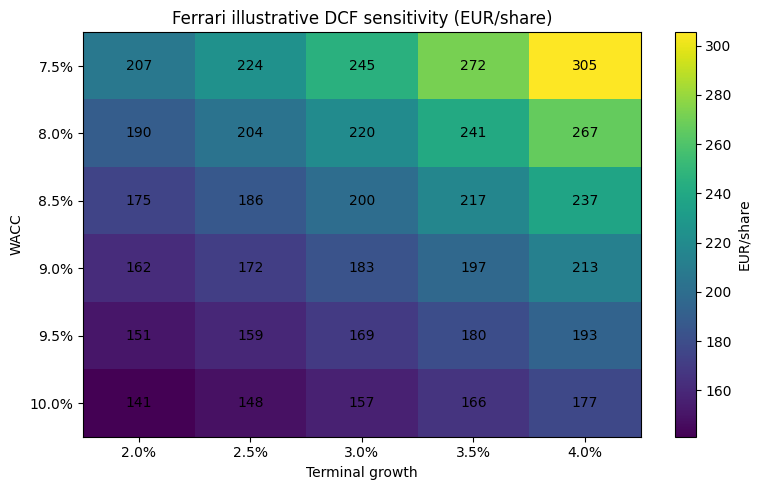

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(sensitivity.values.astype(float), aspect='auto')
ax.set_xticks(range(len(sensitivity.columns)), sensitivity.columns)
ax.set_yticks(range(len(sensitivity.index)), sensitivity.index)
ax.set_xlabel('Terminal growth')
ax.set_ylabel('WACC')
ax.set_title('Ferrari illustrative DCF sensitivity (EUR/share)')
for i in range(sensitivity.shape[0]):
    for j in range(sensitivity.shape[1]):
        ax.text(j, i, f'{sensitivity.iloc[i,j]:.0f}', ha='center', va='center')
fig.colorbar(im, ax=ax, label='EUR/share')
fig.tight_layout()
fig.savefig(CHARTS / 'ferrari_dcf_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

## Interview-ready conclusion

- **Hermes** ranks first on operating quality because of exceptional margins and a large net-cash position.
- **Ferrari** combines high margins with strong recent cash-flow momentum, but quality and valuation must be assessed separately.
- **Moncler** remains cash-rich but showed softer FY2025 growth and EBIT momentum.
- **Brunello Cucinelli** has the strongest revenue growth but more leverage and investment intensity.
- **LVMH** retains unmatched scale and cash generation, while its 2023-2025 revenue and margin trend weakened.

The correct claim is: **“This model identifies operating-quality leaders within a limited peer set.”** It does not establish which security should be bought.